In [140]:
import polars as pl
import numpy as np
import xarray as xr
from jetutils.definitions import DATERANGE, xarray_to_polars, polars_to_xarray
from jetutils.plots import COLORS
from jetutils.anyspell import get_persistent_spell_times_from_som, get_persistent_jet_spells
from jetutils.data import open_dataarray
from simpsom_dask.simpsom import Simpsom
from simpsom_dask.diagnostics import compute_transmat
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, Normalize
import colormaps
import datetime
import polars_st as st
import geopandas as gpd

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline

The IPython.extensions.autoreload extension is already loaded. To reload it, use:
  %reload_ext IPython.extensions.autoreload


## overturnings

In [94]:
def to_xarray(events: st.GeoDataFrame, dummy_da: xr.DataArray, varname: str) -> xr.DataArray:
    dummy_da = dummy_da.rename("dummy")
    da_df = pl.from_pandas(dummy_da.to_dataframe().reset_index())
    orig_times = da_df["time"]
    timedtype = orig_times.dtype
    da_df = da_df.drop("time", "dummy").cast({"lon": pl.Float32, "lat": pl.Float32})
    da_df = da_df.unique(["lat", "lon"]).sort(["lat", "lon"]).with_columns(geometry=pl.concat_list(["lon", "lat"])).with_columns(geometry=st.from_coords("geometry"))
    da_df = st.GeoDataFrame(da_df)
    events = events.with_columns(pl.col("geometry").st.buffer(0.25))
    if varname == "flag":
        events = events.with_columns(flag=pl.lit(1))
    events = (
        events.select(["time", "geometry", varname])
        .cast({varname: pl.UInt32 if varname == "flag" else pl.Float32})
    )
    events = events.cast({"time": timedtype})
    events = events.filter(pl.col("time").is_in(orig_times.to_list()))
    dummy_da = xr.zeros_like(dummy_da, dtype=np.float32)
    events = events.st.sjoin(da_df, on="geometry", how="inner", predicate="contains")
    events = events.unique(["time", "lat", "lon"])
    events_da = xr.DataArray.from_series(
        events[["time", varname, "lat", "lon"]]
        .to_pandas()
        .set_index(["time", "lat", "lon"])[varname]
    ).fillna(0)
    dummy_da.loc[
        {
            "time": events_da.time.values,
            "lat": events_da.lat.values,
            "lon": events_da.lon.values,
        }
    ] = events_da
    return dummy_da

df = st.from_geopandas(gpd.read_parquet("/Users/bandelol/Documents/code_local/data/era5_av_overturnings_250hPa_1959-2022.parquet"))
df = df.rename({"date": "time"})

In [127]:
from tqdm import tqdm
from itertools import product
from IPython.display import clear_output
overturnings = {}

for orientation in ["cyclonic", "anticyclonic"]:
    overturnings[orientation] = []
    for year in tqdm(df["time"].dt.year().unique()):
        df_ = df.filter(pl.col("orientation") == orientation, pl.col("time").dt.year() == year)
        coords = {
            "time": df_["time"].unique().to_numpy(),
            "lat": np.arange(15, 80.5, .5),
            "lon": np.arange(-80, 40.5, .5),
        }
        dummy_da = xr.DataArray(np.zeros([len(a) for a in coords.values()], dtype=bool), coords=coords, name="dummy")
        overturnings[orientation].append(to_xarray(events=df_, dummy_da=dummy_da, varname="flag"))
        
        clear_output()
    overturnings[orientation] = xr.concat(overturnings[orientation], dim="time")
overturnings = xr.Dataset(overturnings).reindex(time=DATERANGE, fill_value=0)

100%|██████████| 64/64 [06:37<00:00,  6.20s/it]


## ERA5

In [141]:
labels = open_dataarray("/Users/bandelol/Documents/code_local/data/labels_som_4_4_pbc_euclidean.nc")
net = Simpsom(4, 4)
coords = net.neighborhoods.coordinates
populations = xarray_to_polars(labels).group_by("labels").len().sort("labels")["len"].to_numpy()

In [143]:
timestepwise = []
group = [] 
for i, (_, group_) in enumerate(labels.groupby(labels.time.dt.dayofyear).groups.items()):
    group.append(group_)
    if i % 7 != 6:
        continue
    group = np.concatenate(group)
    coords = net.neighborhoods.coordinates[labels[group]]
    unique, count = np.unique(labels[group], return_counts=True)
    
    coordsmax = coords.max(axis=0, keepdims=True)
    thetas = coords / coordsmax * 2 * np.pi
    xi, zeta = np.cos(thetas), np.sin(thetas)
    mxi, mzeta = np.mean(xi, axis=0), np.mean(zeta, axis=0)
    com = np.arctan2(-mzeta, -mxi) + np.pi
    com = com / 2 / np.pi * coordsmax
    
    maxdx = net.x
    maxdy = net.y
    dx = np.abs(coords[:, 0] - com[0, 0])
    dy = np.abs(coords[:, 1] - com[0, 1])
    mask_periodic = dx > maxdx
    dx[mask_periodic] = maxdx - dx[mask_periodic]
    mask_periodic = dy > maxdy
    dy[mask_periodic] = maxdy - dy[mask_periodic]
    stdx = np.sqrt(np.sum(dx ** 2) / (len(dx) - 1))
    stdy = np.sqrt(np.sum(dy ** 2) / (len(dy) - 1))
    variab = np.asarray([stdx, stdy])
    timestepwise.append((com.squeeze(), variab.squeeze(), unique, count))
    group = []
    
com = np.asarray([step_[0] for step_ in timestepwise])
com_std = np.asarray([step_[1] for step_ in timestepwise])

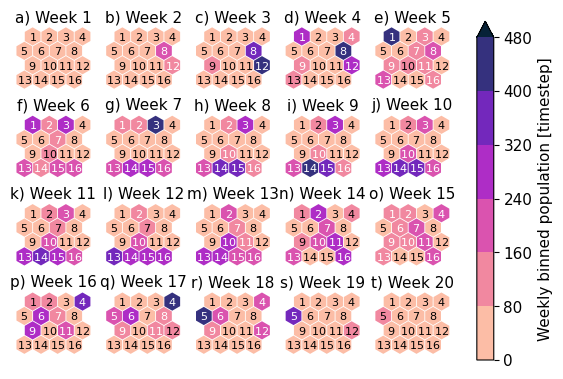

In [146]:
from jetutils.plots import TEXTWIDTH_IN, MaxNLocator, ScalarMappable, ascii_lowercase
fig, axes = plt.subplots(4, 5, figsize=(TEXTWIDTH_IN, 4.4), tight_layout=False, subplot_kw={"aspect": "equal"})
cmap = colormaps.bubblegum_r
max_ = np.quantile([np.amax(timestepwis[3]) for timestepwis in timestepwise], 0.8)
norm = BoundaryNorm(MaxNLocator(6).tick_values(0, max_), cmap.N, extend="max")
im = ScalarMappable(norm, cmap)
coords = net.neighborhoods.coordinates
cbar = fig.colorbar(im, ax=axes)
cbar.ax.set_ylabel("Weekly binned population [timestep]")
for tsw, (i, ax) in zip(timestepwise, enumerate(axes.ravel())):
    step = i + 1
    letter = ascii_lowercase[i]
    unique, counts = tsw[2], tsw[3]
    to_plot = np.zeros(net.n_nodes)
    to_plot[unique] = counts
    fig, ax = net.plot_on_map(
        to_plot,
        smooth_sigma=0,
        show=False,
        cmap=cmap,
        norm=norm,
        fig=fig,
        ax=ax,
        draw_cbar=False,
        linewidths=0,
    )
    # ax.errorbar(*com[step], *com_std[step][[1, 0]])
    ax.set_title(f"{letter}) Week {step}", pad=2)
    
    for i, c in enumerate(coords):
        x, y = c
        color = "white" if to_plot[i] > 100 else "black"
        ax.text(x, y, f'${i + 1}$', va='center', ha='center', color=color, fontsize=8)
fig.set_tight_layout(False)

In [135]:
props_as_df = pl.read_parquet("/Users/bandelol/Documents/code_local/data/exp6/props_as_df.parquet")
spells_STJ = get_persistent_jet_spells(props_as_df.with_columns(pl.col("com_speed").replace(0, None)), "com_speed", 0.8, "STJ", "JJA", minlen=datetime.timedelta(days=4), fill_holes=datetime.timedelta(hours=18))
spells_EDJ = get_persistent_jet_spells(props_as_df.with_columns(pl.col("com_speed").replace(0, None)), "com_speed", 0.85, "EDJ", "JJA", minlen=datetime.timedelta(days=5), fill_holes=datetime.timedelta(hours=18))

In [90]:
spells_EDJ.filter(pl.col("time").dt.year() == 2021)

spell,len,time,relative_time,start,value,range,relative_index
u32,u32,datetime[μs],duration[μs],i64,bool,u32,i32
16,26,2021-07-29 12:00:00,0µs,23050,true,23050,0
16,26,2021-07-29 18:00:00,6h,23050,true,23050,1
16,26,2021-07-30 00:00:00,12h,23050,true,23050,2
16,26,2021-07-30 06:00:00,18h,23050,true,23050,3
16,26,2021-07-30 12:00:00,1d,23050,true,23050,4
…,…,…,…,…,…,…,…
16,26,2021-08-03 18:00:00,5d 6h,23050,true,23050,21
16,26,2021-08-04 00:00:00,5d 12h,23050,true,23050,22
16,26,2021-08-04 06:00:00,5d 18h,23050,true,23050,23


(<Figure size 560x400 with 3 Axes>,
 <Axes: >,
 <matplotlib.colorbar.Colorbar at 0x30d609f90>)

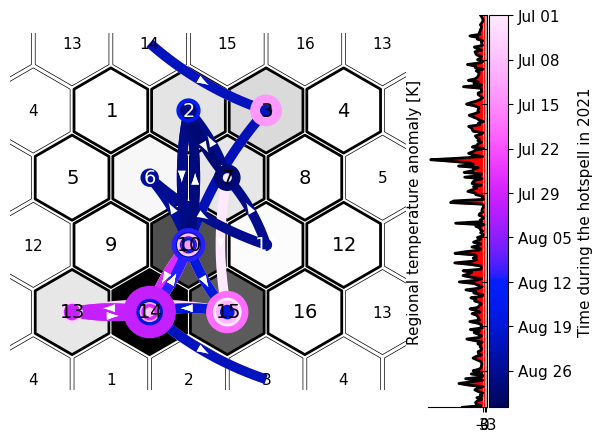

In [91]:
from simpsom_dask.plots import plt_traj_hotspell
time = labels.time
plt_traj_hotspell(4, 4, time.sel(time=(time.dt.year == 2021) & (np.isin(time.dt.month, [7, 8]))), labels, polars_to_xarray(props_as_df.filter(pl.col("jet") == "EDJ")[["time", "com_speed"]], ["time"]))

In [152]:
net = Simpsom(4, 4, sigma=2, sigmaN=0, PBC=True, init="pca")
X = np.random.rand(100, 100)
net.train(X, 20)
label_ = net.predict(X)

PCA weights init


100%|██████████| 20/20 [00:00<00:00, 6420.67it/s]

Memoized


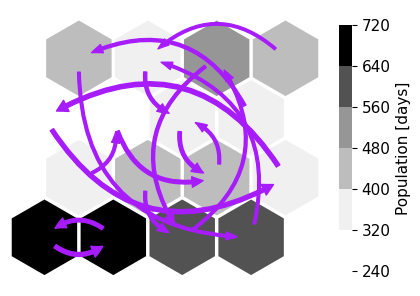

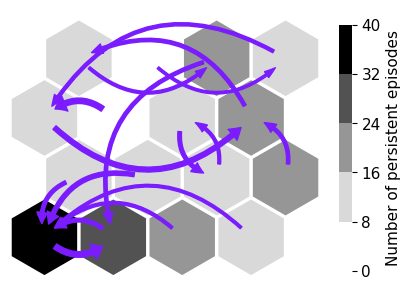

In [92]:
import matplotlib.patches as patches
import polars.selectors as cs
from itertools import product

# What happens before?
rel_ind = -1
spells = get_persistent_spell_times_from_som(
    labels, None, 0, minlen=24, nt_before=-rel_ind, nojune=False, daily=False
)
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})
spells_any = get_persistent_spell_times_from_som(
    labels, None, 0, 1, nt_before=-rel_ind, nojune=False, daily=False
)
spells_any = spells_any.cast(
    {"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")}
)
longest_spell = (
    spells.group_by("value")
    .agg(pl.col("time").filter(pl.col("len") == pl.col("len").max()))
    .explode("time")
    .join(spells, on=["value", "time"])
    .sort("value", "time")
)

labels_masked = spells.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)
labels_any_masked = spells_any.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)
labels_longest_masked = longest_spell.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)

index = pl.int_range(0, 16, eager=True).rename("labels").to_frame()
transitions_any = index.clone()
transitions_spell = index.clone()
transitions_longest = index.clone()

for i in range(16):
    a = labels_any_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_any = transitions_any.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_masked.filter(pl.col("value") == i, pl.col("relative_index") == rel_ind)[
        "labels"
    ].value_counts(sort=True)
    transitions_spell = transitions_spell.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_longest_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_longest = transitions_longest.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )

## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_any_ = transitions_any.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    populations / 4,
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Population [days]"},
)
for i in range(16):
    to_ = transitions_any_.drop("labels").transpose()[f"column_{i}"].arg_max()
    strength = transitions_any_[i, f"trans to {to_}"]
    tail_width = (strength + 1) ** 4
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[0],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[i], coords[to_], **kw))
## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_spell_ = transitions_spell.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    spells_per_cluster["len"].to_numpy(),
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Number of persistent episodes"},
)
for i in range(16):
    to_ = transitions_spell_.drop("labels").transpose()[f"column_{i}"].arg_max()
    strength = transitions_spell_[i, f"trans to {to_}"]
    tail_width = (strength + 1) ** 3
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[1],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[i], coords[to_], **kw))


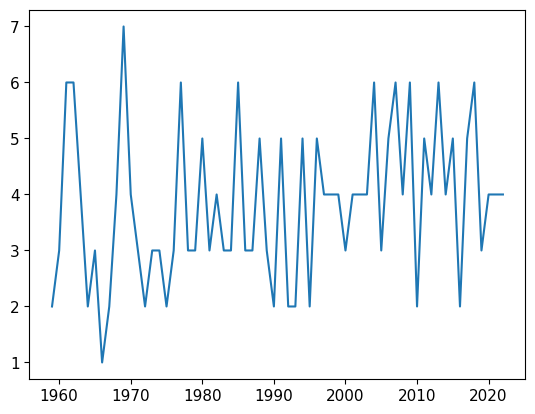

In [93]:
n_spell = spells.group_by(pl.col("time").dt.year(), maintain_order=True).agg(pl.col("spell").rle_id().n_unique())
plt.plot(n_spell["time"], n_spell["spell"])

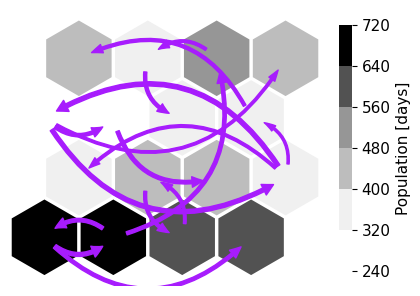

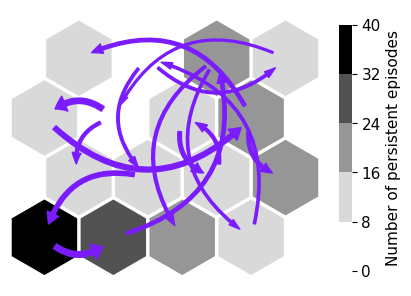

In [94]:
import matplotlib.patches as patches
import polars.selectors as cs
from itertools import product

# What happens before?
rel_ind = -1
spells = get_persistent_spell_times_from_som(
    labels, None, 0, minlen=24, nt_before=-rel_ind, nojune=False, daily=False
)
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})
spells_any = get_persistent_spell_times_from_som(
    labels, None, 0, 1, nt_before=-rel_ind, nojune=False, daily=False
)
spells_any = spells_any.cast(
    {"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")}
)
longest_spell = (
    spells.group_by("value")
    .agg(pl.col("time").filter(pl.col("len") == pl.col("len").max()))
    .explode("time")
    .join(spells, on=["value", "time"])
    .sort("value", "time")
)

labels_masked = spells.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)
labels_any_masked = spells_any.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)
labels_longest_masked = longest_spell.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on="time"
)

index = pl.int_range(0, 16, eager=True).rename("labels").to_frame()
transitions_any = index.clone()
transitions_spell = index.clone()
transitions_longest = index.clone()

for i in range(16):
    a = labels_any_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_any = transitions_any.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_masked.filter(pl.col("value") == i, pl.col("relative_index") == rel_ind)[
        "labels"
    ].value_counts(sort=True)
    transitions_spell = transitions_spell.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_longest_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_longest = transitions_longest.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )

## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_any_ = transitions_any.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    populations / 4,
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Population [days]"},
)
for i in range(16):
    from_ = transitions_any_[f"trans to {i}"].arg_max()
    strength = transitions_any_[from_, f"trans to {i}"]
    tail_width = (strength + 1) ** 4
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[0],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[i], **kw))
## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_spell_ = transitions_spell.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    spells_per_cluster["len"].to_numpy(),
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Number of persistent episodes"},
)
for i in range(16):
    from_ = transitions_spell_[f"trans to {i}"].arg_max()
    strength = transitions_spell_[from_, f"trans to {i}"]
    tail_width = (strength + 1) ** 3
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[1],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[i], **kw))


Text(0.5, 1.0, 'Widening of the distribution before [$\\%$]')

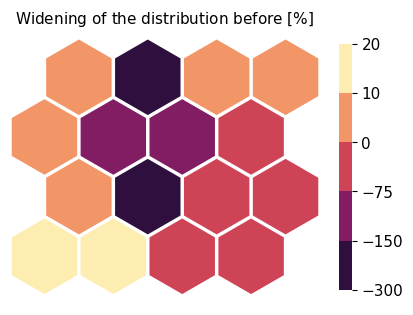

In [131]:
a = (transitions_spell_ > 0.05).sum().cast({cs.all(): pl.Int32()})
b = (transitions_any_ > 0.05).sum().cast({cs.all(): pl.Int32()})
ratio = ((a - b) / a).drop("labels").to_numpy().ravel() * 100
fig, ax = net.plot_on_map(ratio, cmap=colormaps.matter_r, norm=BoundaryNorm([-300, -150, -75, 0, 10, 20], colormaps.matter_r.N))
ax.set_title(r"Widening of the distribution before [$\%$]")

In [102]:
from jetutils.anyspell import get_spells
spells = []
for i in range(net.n_nodes):
    spells.append(get_spells(xarray_to_polars(labels), pl.col("labels") == i, fill_holes=datetime.timedelta(days=1), minlen=datetime.timedelta(days=8)).with_columns(value=i))
spells = pl.concat(spells).sort("time").with_columns(spell=pl.col("spell").rle_id())
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})

In [103]:
labels_pl = xarray_to_polars(labels).cast({"time": pl.Datetime("ms")})
first_day_of_summer = labels_pl[["time"]].group_by(pl.col("time").dt.year().alias("year"), maintain_order=True).agg(pl.col("time").first())

In [112]:
precursor_series = spells.filter(pl.col("value").is_in([12, 13]), pl.col("relative_index") == 0)[["spell", "value", "time"]].with_columns(time_before=pl.datetime_ranges(pl.col("time") - datetime.timedelta(days=10), pl.col("time"), interval="6H", closed="left")).explode("time_before").join(labels_pl, left_on="time_before", right_on="time")

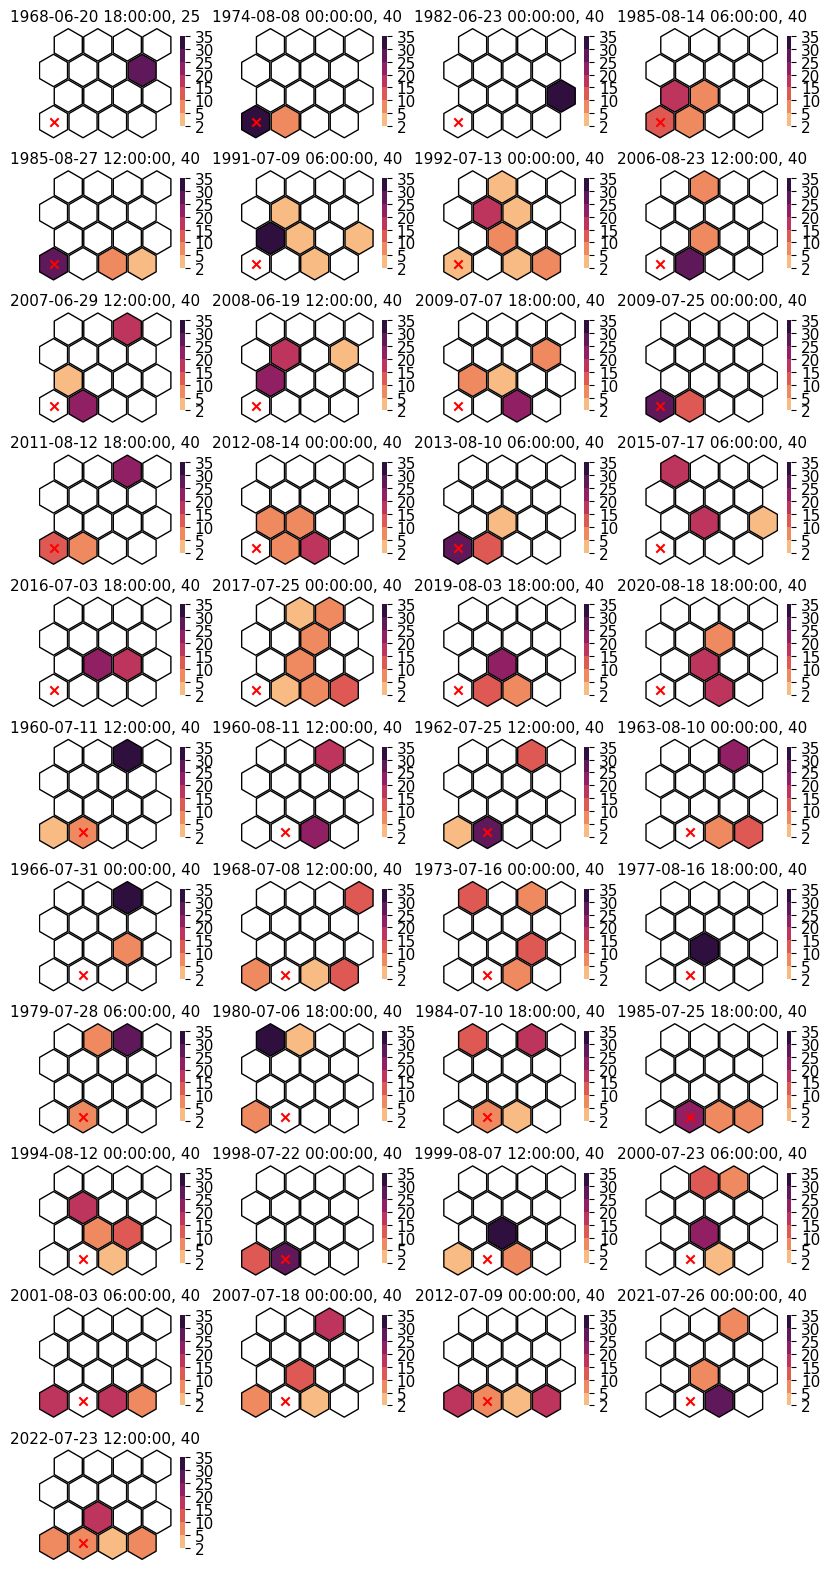

In [118]:
from matplotlib.colors import ListedColormap
from itertools import pairwise


fig, axes = plt.subplots(11, 4, figsize=(10, 20), subplot_kw={"aspect": "equal"})
axes = axes.ravel()
precursor_rle = precursor_series.group_by("spell", maintain_order=True).agg(pl.col("labels").rle(), pl.col("value").first().alias("spell_on")).explode("labels").unnest("labels")
cmap = colormaps.matter
cmap.set_under("white")
norm = BoundaryNorm([2, 5, 10, 15, 20, 25, 30, 35], cmap.N, extend="min")
for i, (spell_number, ouais) in enumerate(precursor_series.sort("value").group_by("spell", maintain_order=True)):
    ax = axes[i]
    spell_on = ouais["value"].first()
    to_plot = pl.Series("labels", np.arange(net.n_nodes)).to_frame().join(ouais.select(pl.col("labels").unique(), pl.col("labels").unique_counts().alias("n")), how="left", on="labels").fill_null(0)["n"].to_numpy()
    fig, ax = net.plot_on_map(to_plot, fig=fig, ax=ax, numbering=False, linewidths=1, edgecolors="black", cmap=cmap, norm=norm, draw_cbar=True)
    ax.scatter(*coords[spell_on], marker="x", color="red")
    ax.set_title(f"{ouais['time'].first()}, {ouais.shape[0]}")
    # for from_, to_ in pairwise(ouais["value"].to_numpy()):
    #     tail_width = 1
    #     head_width = tail_width * 5
    #     style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    #     kw = dict(
    #         arrowstyle=style,
    #         connectionstyle="arc3,rad=.5",
    #         color=COLORS[1],
    #         shrinkA=10,
    #         shrinkB=10,
    #     )
    #     ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[to_], **kw))
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

In [ ]:
precursor_series = spells.filter(pl.col("relative_index") == 0)[["spell", "value", "time"]].with_columns(time_before=pl.datetime_ranges(pl.col("time") - datetime.timedelta(days=10), pl.col("time"), interval="6H", closed="left")).explode("time_before").join(labels_pl, left_on=["time_before"], right_on=["time"])

In [143]:
i1 = np.arange(32).reshape((8, 4))[np.repeat(np.arange(8), 2), np.tile([0, 1], 8)]
i2 = np.arange(32).reshape((8, 4))[np.repeat(np.arange(8), 2), np.tile([2, 3], 8)]

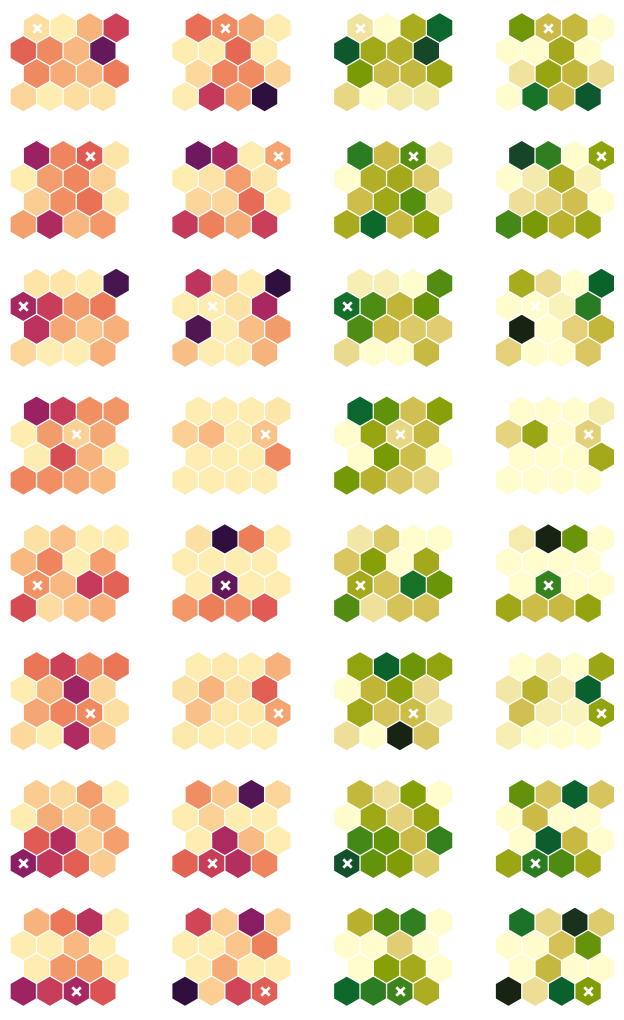

In [144]:
precursors_grouped = precursor_series.group_by(["value", "spell"]).agg(pl.col("labels").unique(), pl.col("labels").unique_counts().alias("n")).explode("labels", "n")
precursors_grouped = precursors_grouped[["spell", "value"]].unique(["spell", "value"]).join(precursors_grouped[["labels"]].unique("labels"), how="cross").join(precursors_grouped, on=["spell", "value", "labels"], how="left").fill_null(0)
precursors_grouped = precursors_grouped.group_by("labels", "value").agg(pl.col("n").mean().alias("mean_n"), pl.col("n").std().alias("std_n")).sort("value", "labels")
fig, axes = plt.subplots(8, 4, figsize=(8, 13), subplot_kw={"aspect": "equal"})
i1 = np.arange(32).reshape((8, 4))[np.repeat(np.arange(8), 2), np.tile([0, 1], 8)]
i2 = np.arange(32).reshape((8, 4))[np.repeat(np.arange(8), 2), np.tile([2, 3], 8)]
axes = np.concatenate([axes.ravel()[i1], axes.ravel()[i2]])
cmap_mean = colormaps.matter
cmap_std = colormaps.speed
norm_mean = Normalize(precursors_grouped["mean_n"].quantile(0.01), precursors_grouped["mean_n"].quantile(0.99), cmap_mean.N)
norm_std = Normalize(precursors_grouped["std_n"].quantile(0.01), precursors_grouped["std_n"].quantile(0.99), cmap_std.N)

for i, (pe_cluster, ouais) in enumerate(precursors_grouped.group_by("value", maintain_order=True)):
    ax = axes[i]
    fig, ax = net.plot_on_map(ouais["mean_n"].to_numpy(), fig=fig, ax=ax, cmap=cmap_mean, norm=norm_mean, draw_cbar=False)
    ax.scatter(*coords[pe_cluster[0]], marker="x", color="white", lw=2)
for j, (pe_cluster, ouais) in enumerate(precursors_grouped.group_by("value", maintain_order=True)):
    ax = axes[1 + i + j]
    fig, ax = net.plot_on_map(ouais["std_n"].to_numpy(), fig=fig, ax=ax, cmap=cmap_std, norm=norm_std, draw_cbar=False)
    ax.scatter(*coords[pe_cluster[0]], marker="x", color="white", lw=2)

Text(0.5, 1.0, 'Proba of jumping to a persistent episode [$\\%$]')

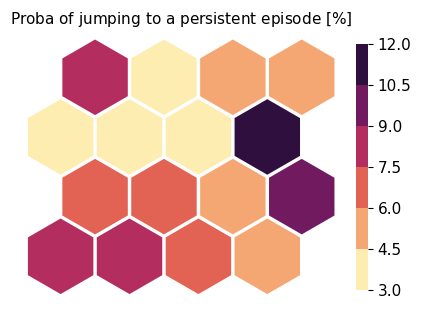

In [106]:
fig, ax = net.plot_on_map((transitions_spell.drop("labels").sum_horizontal() / transitions_any.drop("labels").sum_horizontal()).to_numpy() * 100, discretify=True)
ax.set_title(r"Proba of jumping to a persistent episode [$\%$]")

## CESM

In [2]:
labels = open_dataarray("/Users/bandelol/Documents/code_local/data/labels_cesm.nc")
net = Simpsom(4, 4)
coords = net.neighborhoods.coordinates
populations = xarray_to_polars(labels).group_by("labels").len().sort("labels")["len"].to_numpy()

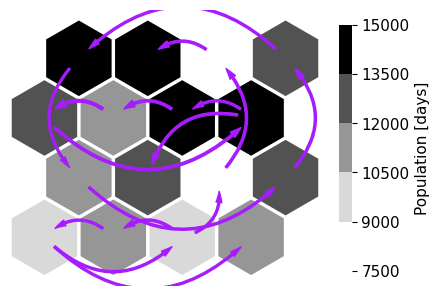

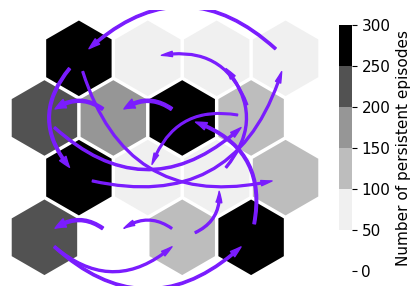

In [3]:
import matplotlib.patches as patches
import polars.selectors as cs
from itertools import product
# What happens before?
rel_ind = -1
spells = get_persistent_spell_times_from_som(
    labels, None, 0, 8, nt_before=-rel_ind, nojune=False, daily=False
)
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})
spells_any = get_persistent_spell_times_from_som(
    labels, None, 0, 1, nt_before=-rel_ind, nojune=False, daily=False
)
spells_any = spells_any.cast(
    {"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")}
)
longest_spell = (
    spells.group_by("value")
    .agg(
        pl.col("time").filter(pl.col("len") == pl.col("len").max()),
        pl.col("member").filter(pl.col("len") == pl.col("len").max())
    )
    ## allows for duplicates, I think it's fine
    .explode("member", "time")
    .join(spells, on=["value", "member", "time"])
    .sort("value", "member", "time")
)

labels_masked = spells.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
labels_any_masked = spells_any.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
labels_longest_masked = longest_spell.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
index = pl.int_range(0, 16, eager=True).rename("labels").to_frame()
transitions_any = index.clone()
transitions_spell = index.clone()
transitions_longest = index.clone()

for i in range(16):
    a = labels_any_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_any = transitions_any.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_masked.filter(pl.col("value") == i, pl.col("relative_index") == rel_ind)[
        "labels"
    ].value_counts(sort=True)
    transitions_spell = transitions_spell.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_longest_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_longest = transitions_longest.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )

## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_any_ = transitions_any.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    populations,
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Population [days]"},
)
for i in range(16):
    from_ = transitions_any_[f"trans to {i}"].arg_max()
    strength = transitions_any_[from_, f"trans to {i}"]
    tail_width = (strength + 1) ** 2
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[0],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[i], **kw))

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_spell_ = transitions_spell.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    spells_per_cluster["len"].to_numpy(),
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Number of persistent episodes"},
)
for i in range(16):
    from_ = transitions_spell_[f"trans to {i}"].arg_max()
    strength = transitions_spell_[from_, f"trans to {i}"]
    tail_width = (strength + 1) ** 2
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[1],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[i], **kw))

In [4]:
from jetutils.anyspell import get_spells
spells = []
for i in range(net.n_nodes):
    spells.append(get_spells(xarray_to_polars(labels), pl.col("labels") == i, fill_holes=datetime.timedelta(days=1), minlen=datetime.timedelta(days=8)).with_columns(value=i))
spells = pl.concat(spells).sort(["member", "time"]).with_columns(spell=pl.col("spell").rle_id().over("member"))
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})

In [5]:
labels_pl = xarray_to_polars(labels).cast({"time": pl.Datetime("ms")})

In [ ]:
precursor_series = spells.filter(pl.col("relative_index") == 0)[["spell", "value", "member", "time"]].with_columns(time_before=pl.datetime_ranges(pl.col("time") - datetime.timedelta(days=10), pl.col("time"), interval="6H", closed="left")).explode("time_before").join(labels_pl, left_on=["member", "time_before"], right_on=["member", "time"])
# pl.col("value").is_in([4, 5, 6, 7, 8]), 

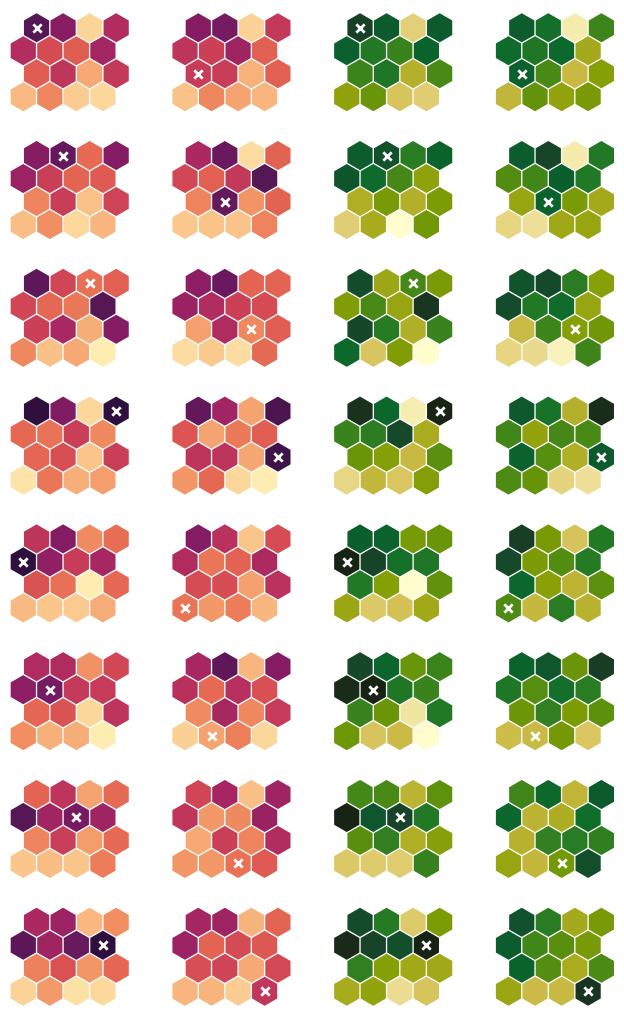

In [83]:
precursors_grouped = precursor_series.group_by(["value", "spell", "member"]).agg(pl.col("labels").unique(), pl.col("labels").unique_counts().alias("n")).explode("labels", "n")
precursors_grouped = precursors_grouped[["member", "spell", "value"]].unique(["member", "spell", "value"]).join(precursors_grouped[["labels"]].unique("labels"), how="cross").join(precursors_grouped, on=["member", "spell", "value", "labels"], how="left").fill_null(0)
precursors_grouped = precursors_grouped.group_by("labels", "value").agg(pl.col("n").mean().alias("mean_n"), pl.col("n").std().alias("std_n")).sort("value", "labels")
fig, axes = plt.subplots(8, 4, figsize=(8, 13), subplot_kw={"aspect": "equal"})
axes = axes.T.ravel()
cmap_mean = colormaps.matter
cmap_std = colormaps.speed
norm_mean = Normalize(precursors_grouped["mean_n"].quantile(0.01), precursors_grouped["mean_n"].quantile(0.99), cmap_mean.N)
norm_std = Normalize(precursors_grouped["std_n"].quantile(0.01), precursors_grouped["std_n"].quantile(0.99), cmap_std.N)

for i, (pe_cluster, ouais) in enumerate(precursors_grouped.group_by("value", maintain_order=True)):
    ax = axes[i]
    fig, ax = net.plot_on_map(ouais["mean_n"].to_numpy(), fig=fig, ax=ax, cmap=cmap_mean, norm=norm_mean, draw_cbar=False)
    ax.scatter(*coords[pe_cluster[0]], marker="x", color="white", lw=2)
for j, (pe_cluster, ouais) in enumerate(precursors_grouped.group_by("value", maintain_order=True)):
    ax = axes[1 + i + j]
    fig, ax = net.plot_on_map(ouais["std_n"].to_numpy(), fig=fig, ax=ax, cmap=cmap_std, norm=norm_std, draw_cbar=False)
    ax.scatter(*coords[pe_cluster[0]], marker="x", color="white", lw=2)

IndexError: index 52 is out of bounds for axis 0 with size 52

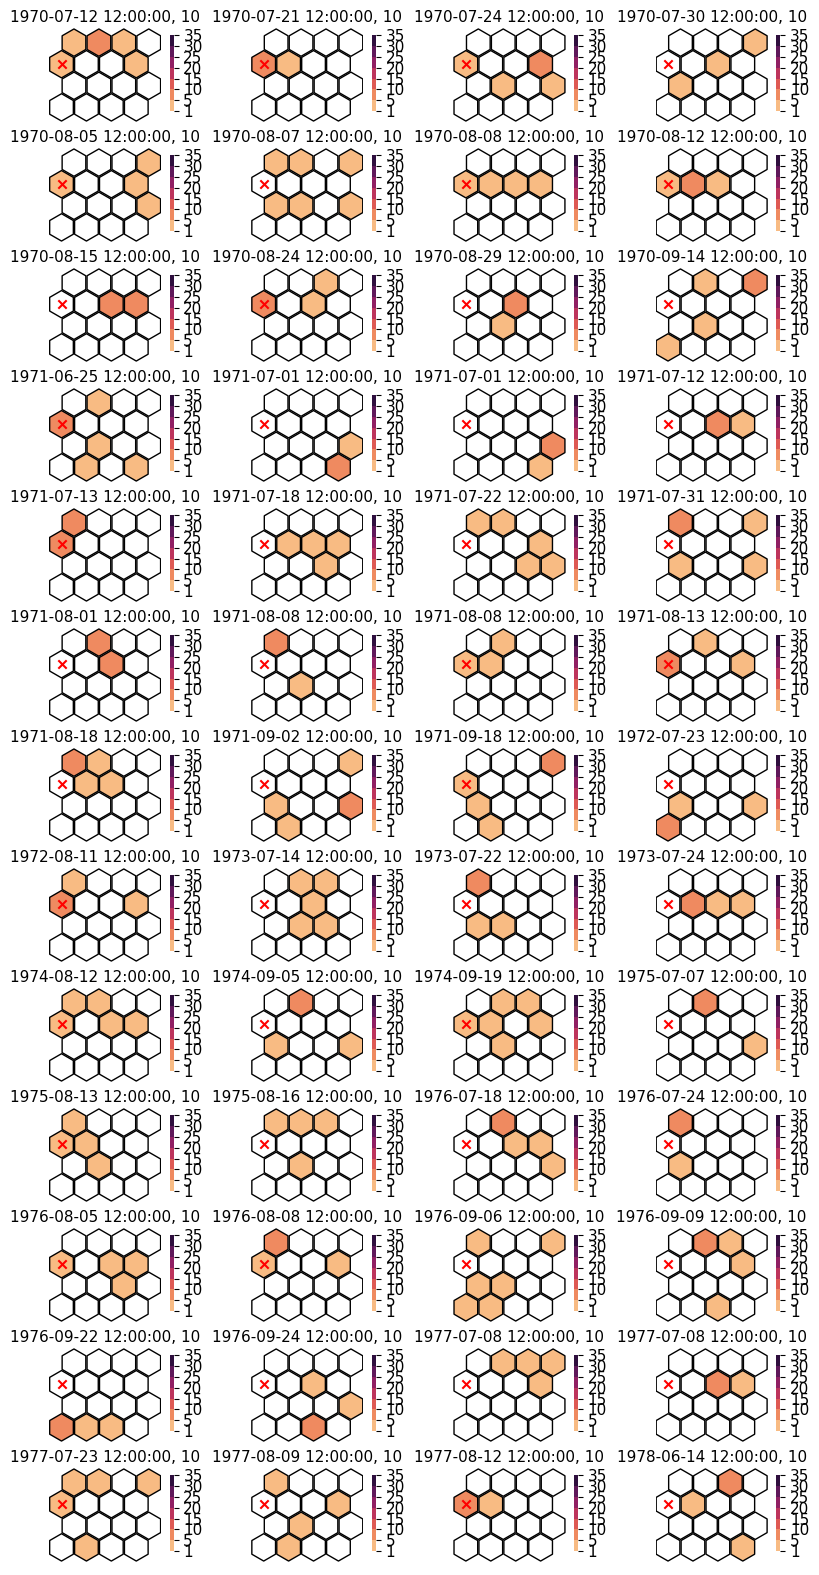

In [9]:
from matplotlib.colors import ListedColormap
from itertools import pairwise


fig, axes = plt.subplots(13, 4, figsize=(10, 20), subplot_kw={"aspect": "equal"})
axes = axes.ravel()
cmap = colormaps.matter
cmap.set_under("white")
norm = BoundaryNorm([1, 5, 10, 15, 20, 25, 30, 35], cmap.N, extend="min")
for i, (spell_number, ouais) in enumerate(precursor_series.sort("value", "time", "member").group_by(["member", "spell"], maintain_order=True)):
    ax = axes[i]
    spell_on = ouais["value"].first()
    to_plot = pl.Series("labels", np.arange(net.n_nodes)).to_frame().join(ouais.select(pl.col("labels").unique(), pl.col("labels").unique_counts().alias("n")), how="left", on="labels").fill_null(0)["n"].to_numpy()
    fig, ax = net.plot_on_map(to_plot, fig=fig, ax=ax, numbering=False, linewidths=1, edgecolors="black", cmap=cmap, norm=norm, draw_cbar=True)
    ax.scatter(*coords[spell_on], marker="x", color="red")
    ax.set_title(f"{ouais['time'].first()}, {ouais.shape[0]}")
    # for from_, to_ in pairwise(ouais["value"].to_numpy()):
    #     tail_width = 1
    #     head_width = tail_width * 5
    #     style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    #     kw = dict(
    #         arrowstyle=style,
    #         connectionstyle="arc3,rad=.5",
    #         color=COLORS[1],
    #         shrinkA=10,
    #         shrinkB=10,
    #     )
    #     ax.add_patch(patches.FancyArrowPatch(coords[from_], coords[to_], **kw))

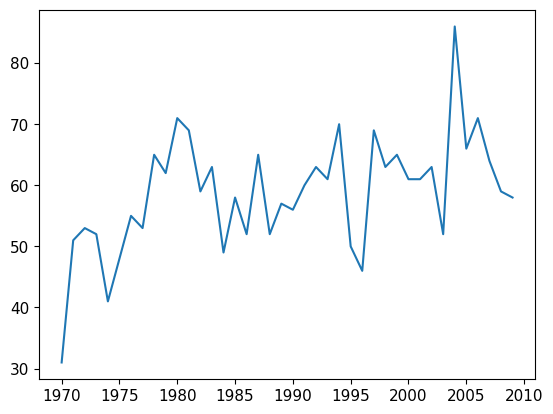

In [38]:
n_spell = spells.group_by(pl.col("time").dt.year(), maintain_order=True).agg(pl.col("spell").rle_id().n_unique()).sort("time")
plt.plot(n_spell["time"], n_spell["spell"])

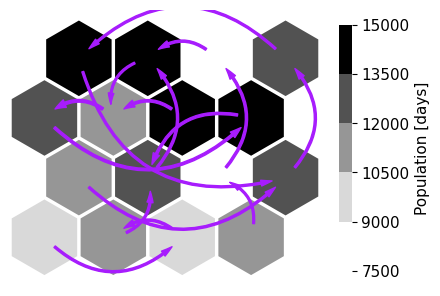

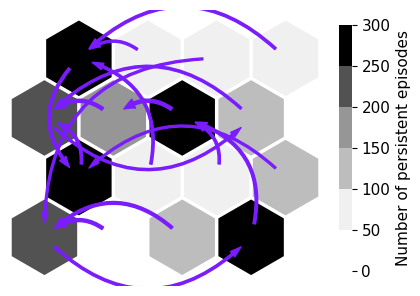

In [136]:
import matplotlib.patches as patches
import polars.selectors as cs
from itertools import product
# What happens before?
rel_ind = -1
spells = get_persistent_spell_times_from_som(
    labels, None, 0, 8, nt_before=-rel_ind, nojune=False, daily=False
)
spells = spells.cast({"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")})
spells_any = get_persistent_spell_times_from_som(
    labels, None, 0, 1, nt_before=-rel_ind, nojune=False, daily=False
)
spells_any = spells_any.cast(
    {"time": pl.Datetime("ms"), "relative_time": pl.Duration("ms")}
)
longest_spell = (
    spells.group_by("value")
    .agg(
        pl.col("time").filter(pl.col("len") == pl.col("len").max()),
        pl.col("member").filter(pl.col("len") == pl.col("len").max())
    )
    ## allows for duplicates, I think it's fine
    .explode("member", "time")
    .join(spells, on=["value", "member", "time"])
    .sort("value", "member", "time")
)

labels_masked = spells.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
labels_any_masked = spells_any.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
labels_longest_masked = longest_spell.join(
    xarray_to_polars(labels).cast({"time": pl.Datetime("ms")}), on=["member","time"]
)
index = pl.int_range(0, 16, eager=True).rename("labels").to_frame()
transitions_any = index.clone()
transitions_spell = index.clone()
transitions_longest = index.clone()

for i in range(16):
    a = labels_any_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_any = transitions_any.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_masked.filter(pl.col("value") == i, pl.col("relative_index") == rel_ind)[
        "labels"
    ].value_counts(sort=True)
    transitions_spell = transitions_spell.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )
    a = labels_longest_masked.filter(
        pl.col("value") == i, pl.col("relative_index") == rel_ind
    )["labels"].value_counts(sort=True)
    transitions_longest = transitions_longest.join(
        a.rename({"count": f"trans to {i}"}), on="labels", how="left"
    )

## spells per cluster

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_any_ = transitions_any.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    populations,
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Population [days]"},
)
for i in range(16):
    to_ = transitions_any_.drop("labels").transpose()[f"column_{i}"].arg_max()
    strength = transitions_any_[i, f"trans to {to_}"]
    tail_width = (strength + 1) ** 2
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[0],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[i], coords[to_], **kw))

spells_per_cluster = (
    spells.filter(pl.col("relative_index") == 0).group_by("value").len()
)
spells_per_cluster = (
    pl.Series("value", np.arange(net.n_nodes))
    .to_frame()
    .join(spells_per_cluster, how="left", on="value")
    .fill_null(0)
)
cmap = colormaps.greys
transitions_spell_ = transitions_spell.fill_null(0).with_columns(
    cs.contains("trans") / pl.sum_horizontal(cs.contains("trans"))
)
fig, ax = net.plot_on_map(
    spells_per_cluster["len"].to_numpy(),
    cmap=cmap,
    discretify=True,
    cbar_kwargs={"shrink": 0.8, "label": "Number of persistent episodes"},
)
for i in range(16):
    to_ = transitions_spell_.drop("labels").transpose()[f"column_{i}"].arg_max()
    strength = transitions_spell_[i, f"trans to {to_}"]
    tail_width = (strength + 1) ** 2
    head_width = tail_width * 3
    style = f"Simple, tail_width={tail_width:.3f}, head_width={head_width:.3f}, head_length=8"
    kw = dict(
        arrowstyle=style,
        connectionstyle="arc3,rad=.5",
        color=COLORS[1],
        shrinkA=10,
        shrinkB=10,
    )
    ax.add_patch(patches.FancyArrowPatch(coords[i], coords[to_], **kw))

(<Figure size 500x400 with 2 Axes>, <Axes: >)

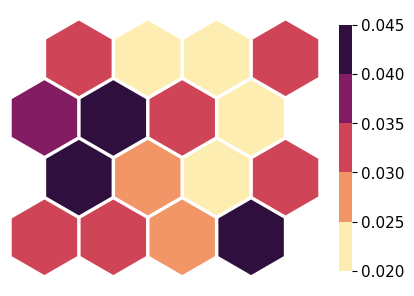

In [137]:
net.plot_on_map((transitions_spell.drop("labels").sum_horizontal() / transitions_any.drop("labels").sum_horizontal()).to_numpy(), discretify=True)

(<Figure size 500x400 with 2 Axes>, <Axes: >)

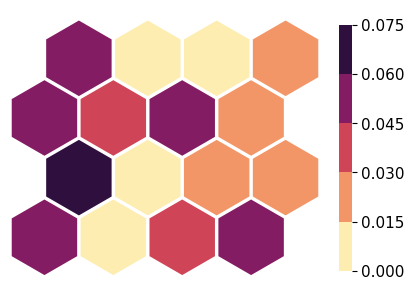

In [138]:
net.plot_on_map((transitions_spell.drop("labels").sum() / transitions_any.drop("labels").sum()).to_numpy().ravel(), discretify=True)

(<Figure size 500x400 with 2 Axes>, <Axes: >)

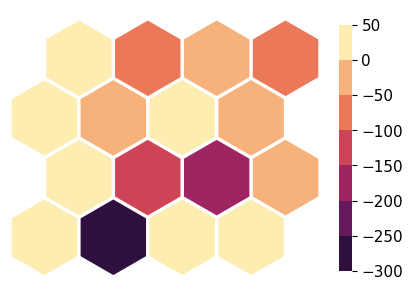

In [139]:
a = (transitions_spell_ > 0.05).sum().cast({cs.all(): pl.Int32()})
b = (transitions_any_ > 0.05).sum().cast({cs.all(): pl.Int32()})
ratio = ((a - b) / a).drop("labels").to_numpy().ravel() * 100
net.plot_on_map(ratio, cmap=colormaps.matter_r, norm=BoundaryNorm(np.linspace(-300, 50, 8), colormaps.matter_r.N))